In [1]:

"""
Model B: LightGBM Implementation
シート圧センサ → COP (X, Y) 推定

特徴:
- LightGBMによる非線形回帰
- LOGO-CV (Leave-One-Group-Out Cross Validation)
- 特徴量重要度分析
- LabVIEW用のモデルエクスポート (ONNX形式)
- 詳細な評価指標とビジュアライゼーション
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import glob
import pickle

from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor

import lightgbm as lgb

# 日本語フォント設定 (必要に応じて)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
pkl_path_list = glob.glob(r"C:\Users\youli\Desktop\code\20251118_COPモドキ\20251214home\data\2F\*.pkl")
pkl_path_list
dfs = []
for path in pkl_path_list:
    with open(path, "rb") as f:
        df = pickle.load(f)
        dfs.append(df)

# 縦に連結
df_all = pd.concat(dfs, axis=0, ignore_index=True)
print(df_all.subject_id.unique())

[10 11  2  3  4  5  6  7  8  9]


In [3]:
df_all.columns

Index(['time', 'COP_X', 'COP_Y', 'steer', 'trg', 'pedal', '平均圧力_1', '最低圧力_1',
       'ピーク圧力_1', '接触域 (cm²)_1', '選択領域(cm²)_1', '接触 %_1', '荷重(N)_1', '標準偏差_1',
       '平均_1', '圧力中心行_1', '圧力中心列_1', '平均圧力_2', '最低圧力_2', 'ピーク圧力_2',
       '接触域 (cm²)_2', '選択領域(cm²)_2', '接触 %_2', '荷重(N)_2', '標準偏差_2', '平均_2',
       '圧力中心行_2', '圧力中心列_2', 'subject_id'],
      dtype='object')

In [4]:
# 平滑化する列のリスト
smooth_cols = ['接触 %_1', '接触 %_2', '荷重(N)_1', '荷重(N)_2', 
               '圧力中心列_1', '圧力中心列_2', '圧力中心行_1',
               'COP_X', 'COP_Y']

# ウィンドウサイズを設定。奇数が良いので3や5。
window_size = 5

# 各列に対して移動平均を適用。ただし、時系列順に並んでいることが前提。
for col in smooth_cols:
    df_all[col] = df_all[col].rolling(window=window_size, center=True).mean()

# 最初と最後のNaNを処理。center=Trueの場合、両端にNaNができる。前方/後方埋めや削除。
# ここでは、前方埋め（ffill）と後方埋め（bfill）を組み合わせる。
df_all[smooth_cols] = df_all[smooth_cols].ffill().bfill()

# 中間表現を再計算
df_all['前後接触バランス'] = df_all['接触 %_1'] - df_all['接触 %_2']
df_all['前後荷重バランス'] = df_all['荷重(N)_1'] - df_all['荷重(N)_2']
df_all['ねじれ'] = df_all['圧力中心列_1'] - df_all['圧力中心列_2']
df_all['Mx_norm'] = (df_all['荷重(N)_1'] * df_all['圧力中心列_1'] + df_all['荷重(N)_2'] * df_all['圧力中心列_2']) / (df_all['荷重(N)_1']+df_all['荷重(N)_2'] )

In [5]:
df_all.columns

Index(['time', 'COP_X', 'COP_Y', 'steer', 'trg', 'pedal', '平均圧力_1', '最低圧力_1',
       'ピーク圧力_1', '接触域 (cm²)_1', '選択領域(cm²)_1', '接触 %_1', '荷重(N)_1', '標準偏差_1',
       '平均_1', '圧力中心行_1', '圧力中心列_1', '平均圧力_2', '最低圧力_2', 'ピーク圧力_2',
       '接触域 (cm²)_2', '選択領域(cm²)_2', '接触 %_2', '荷重(N)_2', '標準偏差_2', '平均_2',
       '圧力中心行_2', '圧力中心列_2', 'subject_id', '前後接触バランス', '前後荷重バランス', 'ねじれ',
       'Mx_norm'],
      dtype='object')

In [6]:
# =========================================================
# 設定
# =========================================================
# features = [
#     '接触 %_1', 
#     '荷重(N)_1',
#     '圧力中心行_1', '圧力中心列_1', 
#     '荷重(N)_2', '圧力中心列_2',
#     '前後バランス' 
#     # '平均圧力_2',
# ]

features = [
    '圧力中心列_1','圧力中心列_2','圧力中心行_1',
       '前後接触バランス', '前後荷重バランス', 'ねじれ',
       'Mx_norm'
]

target_cols = ['COP_X', 'COP_Y']
cols_to_keep = features + target_cols + ['subject_id']

# ハイパーパラメータ設定
CALIB_SAMPLES = 50
TEST_SUBJECT_ID = 5

# =========================================================
# データ前処理
# =========================================================
def subtract_initial_bias(group, calib_samples=50):
    """
    各被験者の初期値を引いて相対変化量に変換
    """
    initial_X = group[features].iloc[:calib_samples].mean()
    initial_Y = group[target_cols].iloc[:calib_samples].mean()
    
    group_rel = group.copy()
    group_rel[features] = group[features] - initial_X
    group_rel[target_cols] = group[target_cols] - initial_Y
    return group_rel


# =========================================================
# モデル定義
# =========================================================
def create_lightgbm_model(use_standardization=True):
    """
    LightGBMモデルのパイプラインを作成
    
    Args:
        use_standardization: 標準化を使用するかどうか
    
    Returns:
        Pipeline object
    """
    steps = []
    
    if use_standardization:
        # LightGBMは木ベースなので標準化不要だが、
        # 特徴量スケールが大きく異なる場合は有効
        steps.append(('scaler', StandardScaler()))
    
    lgbm_params = {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'max_depth': 4,
        'num_leaves': 15,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,      # L1正則化
        'reg_lambda': 1.0,     # L2正則化
        'random_state': 42,
        'verbose': -1,
        'force_col_wise': True,
    }
    
    # MultiOutputRegressorでCOP_XとCOP_Yを同時に学習
    steps.append(('lgbm', MultiOutputRegressor(lgb.LGBMRegressor(**lgbm_params))))
    
    return Pipeline(steps)


def create_lightgbm_single_target(use_standardization=True):
    """
    単一ターゲット用のLightGBMパイプライン
    """
    steps = []
    
    if use_standardization:
        steps.append(('scaler', StandardScaler()))
    
    lgbm_params = {
        'n_estimators': 500,
        'learning_rate': 0.05,
        'max_depth': 4,
        'num_leaves': 15,
        'min_child_samples': 20,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.1,
        'reg_lambda': 1.0,
        'random_state': 42,
        'verbose': -1,
        'force_col_wise': True,
    }
    
    steps.append(('lgbm', lgb.LGBMRegressor(**lgbm_params)))
    
    return Pipeline(steps)


# =========================================================
# 評価関数
# =========================================================
def calculate_metrics(y_true, y_pred):
    """
    複数の評価指標を計算
    """
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    return {
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    }


# =========================================================
# メイン処理
# =========================================================
def main(df_all):
    """
    Model B のメイン処理
    """
    print("\n" + "="*60)
    print("🚀 Model B (LightGBM) Training Pipeline")
    print("="*60)
    
    # ---------------------------------------------------------
    # 1. データ準備
    # ---------------------------------------------------------
    print("\n[Step 1] Data Preparation")
    temp_df = df_all[cols_to_keep].dropna()
    print(f"Total samples after NaN removal: {len(temp_df)}")
    
    # 初期値引き (相対変化量への変換)
    print("Converting to relative displacement...")
    relative_df = temp_df.groupby('subject_id', group_keys=False).apply(
        lambda g: subtract_initial_bias(g, CALIB_SAMPLES)
    )
    
    # ---------------------------------------------------------
    # 2. Train/Test Split
    # ---------------------------------------------------------
    print(f"\n[Step 2] Train/Test Split")
    print(f"Test Subject ID: {TEST_SUBJECT_ID}")
    
    df_test = relative_df[relative_df['subject_id'] == TEST_SUBJECT_ID]
    df_train_val = relative_df[relative_df['subject_id'] != TEST_SUBJECT_ID]
    
    X_train_val = df_train_val[features]
    y_train_val = df_train_val[target_cols]
    groups_train_val = df_train_val['subject_id']
    
    X_test = df_test[features]
    y_test = df_test[target_cols]
    
    print(f"Training samples: {len(X_train_val)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Number of training subjects: {df_train_val['subject_id'].nunique()}")
    
    # ---------------------------------------------------------
    # 3. モデル学習 (2つのアプローチ)
    # ---------------------------------------------------------
    print("\n[Step 3] Model Training")
    
    # アプローチ1: MultiOutputRegressor (COP_XとCOP_Yを同時学習)
    print("\n--- Approach 1: Multi-Output LightGBM ---")
    model_multi = create_lightgbm_model(use_standardization=False)
    model_multi.fit(X_train_val, y_train_val)
    
    y_pred_multi = model_multi.predict(X_test)
    metrics_multi = {
        'COP_X': calculate_metrics(y_test['COP_X'], y_pred_multi[:, 0]),
        'COP_Y': calculate_metrics(y_test['COP_Y'], y_pred_multi[:, 1])
    }
    
    print("\nMulti-Output Results:")
    for target, metrics in metrics_multi.items():
        print(f"{target}: R2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}")
    
    # アプローチ2: 個別学習 (COP_XとCOP_Yを別々に学習 + ハイパーパラメータ調整)
    print("\n--- Approach 2: Separate LightGBM with Hyperparameter Tuning ---")
    
    trained_models_b = {}
    results = {}
    feature_importances = {}
    
    # ハイパーパラメータグリッド
    param_grid = {
        'lgbm__n_estimators': [300, 400],
        'lgbm__learning_rate': [0.03, 0.05, 0.1],
        'lgbm__max_depth': [3, 4, 5],
        'lgbm__num_leaves': [15, 31],
        'lgbm__reg_alpha': [0.1, 1.0],
        'lgbm__reg_lambda': [1.0, 10.0],
    }
    
    for target in target_cols:
        print(f"\nTraining for {target}...")
        y_train_val_single = df_train_val[target]
        y_test_single = df_test[target]
        
        pipeline = create_lightgbm_single_target(use_standardization=False)
        
        # GridSearchCV with LOGO-CV
        logo = LeaveOneGroupOut()
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=logo,
            scoring='r2',
            n_jobs=-1,
            verbose=0
        )
        
        grid_search.fit(X_train_val, y_train_val_single, groups=groups_train_val)
        
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        trained_models_b[target] = best_model
        
        # 予測 & 評価
        y_pred = best_model.predict(X_test)
        metrics = calculate_metrics(y_test_single, y_pred)
        
        results[target] = {
            'metrics': metrics,
            'y_true': y_test_single,
            'y_pred': y_pred,
            'best_params': best_params
        }
        
        # 特徴量重要度
        lgbm_model = best_model.named_steps['lgbm']
        feature_importances[target] = lgbm_model.feature_importances_
        
        print(f"  Best params: {best_params}")
        print(f"  R2={metrics['R2']:.4f}, RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}")
    
    # ---------------------------------------------------------
    # 4. モデル保存
    # ---------------------------------------------------------
    print("\n[Step 4] Saving Models")
    
    artifacts_b = {
        'models': trained_models_b,
        'model_multi': model_multi,
        'features': features,
        'targets': target_cols,
        'calib_samples': CALIB_SAMPLES,
        'test_subject_id': TEST_SUBJECT_ID,
        'results': results,
        'feature_importances': feature_importances
    }
    
    joblib.dump(artifacts_b, 'model_b_lightgbm.pkl')
    print("✅ Model saved: 'model_b_lightgbm.pkl'")
    
    # ---------------------------------------------------------
    # 5. 特徴量重要度の可視化
    # ---------------------------------------------------------
    print("\n[Step 5] Feature Importance Analysis")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for idx, target in enumerate(target_cols):
        importances = feature_importances[target]
        sorted_idx = np.argsort(importances)[::-1]
        
        axes[idx].barh(range(len(features)), importances[sorted_idx], color='skyblue')
        axes[idx].set_yticks(range(len(features)))
        axes[idx].set_yticklabels([features[i] for i in sorted_idx])
        axes[idx].set_xlabel('Importance')
        axes[idx].set_title(f'Feature Importance - {target}')
        axes[idx].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('model_b_feature_importance.png', dpi=150, bbox_inches='tight')
    print("✅ Feature importance plot saved: 'model_b_feature_importance.png'")
    
    # ---------------------------------------------------------
    # 6. 予測結果の可視化
    # ---------------------------------------------------------
    print("\n[Step 6] Visualization")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 時系列プロット
    for idx, target in enumerate(target_cols):
        res = results[target]
        
        # 時系列
        axes[idx, 0].plot(res['y_true'].values, label='True', color='black', alpha=0.7, linewidth=1.5)
        axes[idx, 0].plot(res['y_pred'], label='Predicted', color='red', linestyle='--', alpha=0.8, linewidth=1.5)
        axes[idx, 0].set_title(f"{target} - Time Series (R²={res['metrics']['R2']:.4f})")
        axes[idx, 0].set_xlabel('Sample Index')
        axes[idx, 0].set_ylabel(target)
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)
        
        # 散布図
        axes[idx, 1].scatter(res['y_true'], res['y_pred'], alpha=0.5, s=10)
        
        # 理想ライン
        min_val = min(res['y_true'].min(), res['y_pred'].min())
        max_val = max(res['y_true'].max(), res['y_pred'].max())
        axes[idx, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        
        axes[idx, 1].set_xlabel(f'True {target}')
        axes[idx, 1].set_ylabel(f'Predicted {target}')
        axes[idx, 1].set_title(f"{target} - Scatter Plot")
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, alpha=0.3)
        axes[idx, 1].set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    plt.savefig('model_b_predictions.png', dpi=150, bbox_inches='tight')
    print("✅ Prediction plot saved: 'model_b_predictions.png'")
    
    # ---------------------------------------------------------
    # 7. LabVIEW用エクスポート準備 (テストデータ)
    # ---------------------------------------------------------
    print("\n[Step 7] Generating Test Data for LabVIEW Integration")
    
    # テスト入力の最初の10サンプル
    test_samples = X_test.iloc[:10]
    test_input_df = pd.DataFrame(test_samples.values, columns=features)
    test_input_df.to_csv('model_b_test_input.csv', index=False, encoding='utf-8-sig')
    
    # 期待される出力
    expected_outputs = []
    for target in target_cols:
        y_pred = trained_models_b[target].predict(test_samples)
        expected_outputs.append(y_pred)
    
    expected_output_df = pd.DataFrame(
        np.column_stack(expected_outputs),
        columns=target_cols
    )
    expected_output_df.to_csv('model_b_test_output_expected.csv', index=False, encoding='utf-8-sig')
    
    print("✅ Test data saved:")
    print("   - model_b_test_input.csv (10 samples)")
    print("   - model_b_test_output_expected.csv")
    
    # ---------------------------------------------------------
    # 8. サマリーレポート
    # ---------------------------------------------------------
    print("\n" + "="*60)
    print("📊 Model B Training Summary")
    print("="*60)
    
    print(f"\nModel Type: LightGBM (Gradient Boosting)")
    print(f"Test Subject: {TEST_SUBJECT_ID}")
    print(f"Training Subjects: {df_train_val['subject_id'].nunique()}")
    print(f"\nResults:")
    
    for target in target_cols:
        metrics = results[target]['metrics']
        print(f"\n{target}:")
        print(f"  R² Score:  {metrics['R2']:.4f}")
        print(f"  RMSE:      {metrics['RMSE']:.4f}")
        print(f"  MAE:       {metrics['MAE']:.4f}")
    
    print("\n" + "="*60)


🚀 Model B (LightGBM) Training Pipeline

[Step 1] Data Preparation
Total samples after NaN removal: 87153
Converting to relative displacement...

[Step 2] Train/Test Split
Test Subject ID: 5
Training samples: 78303
Test samples: 8850
Number of training subjects: 9

[Step 3] Model Training

--- Approach 1: Multi-Output LightGBM ---


C:\Users\youli\AppData\Local\Temp\ipykernel_6264\680390390.py:150: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  relative_df = temp_df.groupby('subject_id', group_keys=False).apply(



Multi-Output Results:
COP_X: R2=0.5150, RMSE=0.0089, MAE=0.0058
COP_Y: R2=0.4330, RMSE=0.0180, MAE=0.0141

--- Approach 2: Separate LightGBM with Hyperparameter Tuning ---

Training for COP_X...
  Best params: {'lgbm__learning_rate': 0.1, 'lgbm__max_depth': 5, 'lgbm__n_estimators': 400, 'lgbm__num_leaves': 31, 'lgbm__reg_alpha': 0.1, 'lgbm__reg_lambda': 1.0}
  R2=0.4729, RMSE=0.0093, MAE=0.0062

Training for COP_Y...
  Best params: {'lgbm__learning_rate': 0.03, 'lgbm__max_depth': 3, 'lgbm__n_estimators': 300, 'lgbm__num_leaves': 15, 'lgbm__reg_alpha': 1.0, 'lgbm__reg_lambda': 10.0}
  R2=0.5557, RMSE=0.0159, MAE=0.0122

[Step 4] Saving Models
✅ Model saved: 'model_b_lightgbm.pkl'

[Step 5] Feature Importance Analysis


C:\Users\youli\AppData\Local\Temp\ipykernel_6264\680390390.py:290: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_6264\680390390.py:290: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_6264\680390390.py:290: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_6264\680390390.py:290: UserWarning: Glyph 35302 (\N{CJK UNIFIED IDEOGRAPH-89E6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_6264\680390390.py:290: UserWarning: Glyph 12496 (\N{KATAKANA LETTER BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\youli\AppData\Local\Temp\ipykernel_6264\680390390.py:290: UserWarning: Glyph 12521 (\N{KATAKANA LET

✅ Feature importance plot saved: 'model_b_feature_importance.png'

[Step 6] Visualization
✅ Prediction plot saved: 'model_b_predictions.png'

[Step 7] Generating Test Data for LabVIEW Integration
✅ Test data saved:
   - model_b_test_input.csv (10 samples)
   - model_b_test_output_expected.csv

📊 Model B Training Summary

Model Type: LightGBM (Gradient Boosting)
Test Subject: 5
Training Subjects: 9

Results:

COP_X:
  R² Score:  0.4729
  RMSE:      0.0093
  MAE:       0.0062

COP_Y:
  R² Score:  0.5557
  RMSE:      0.0159
  MAE:       0.0122



TypeError: cannot unpack non-iterable NoneType object

c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35302 (\N{CJK UNIFIED IDEOGRAPH-89E6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\youli\Desktop\code\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12496 (\N{KATAKANA LETTER

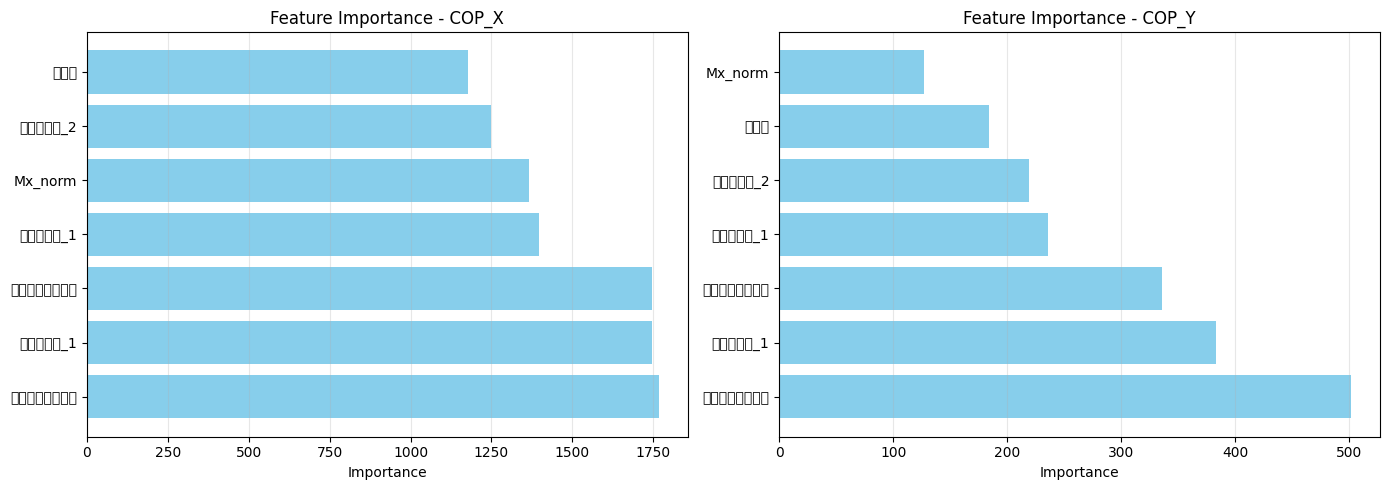

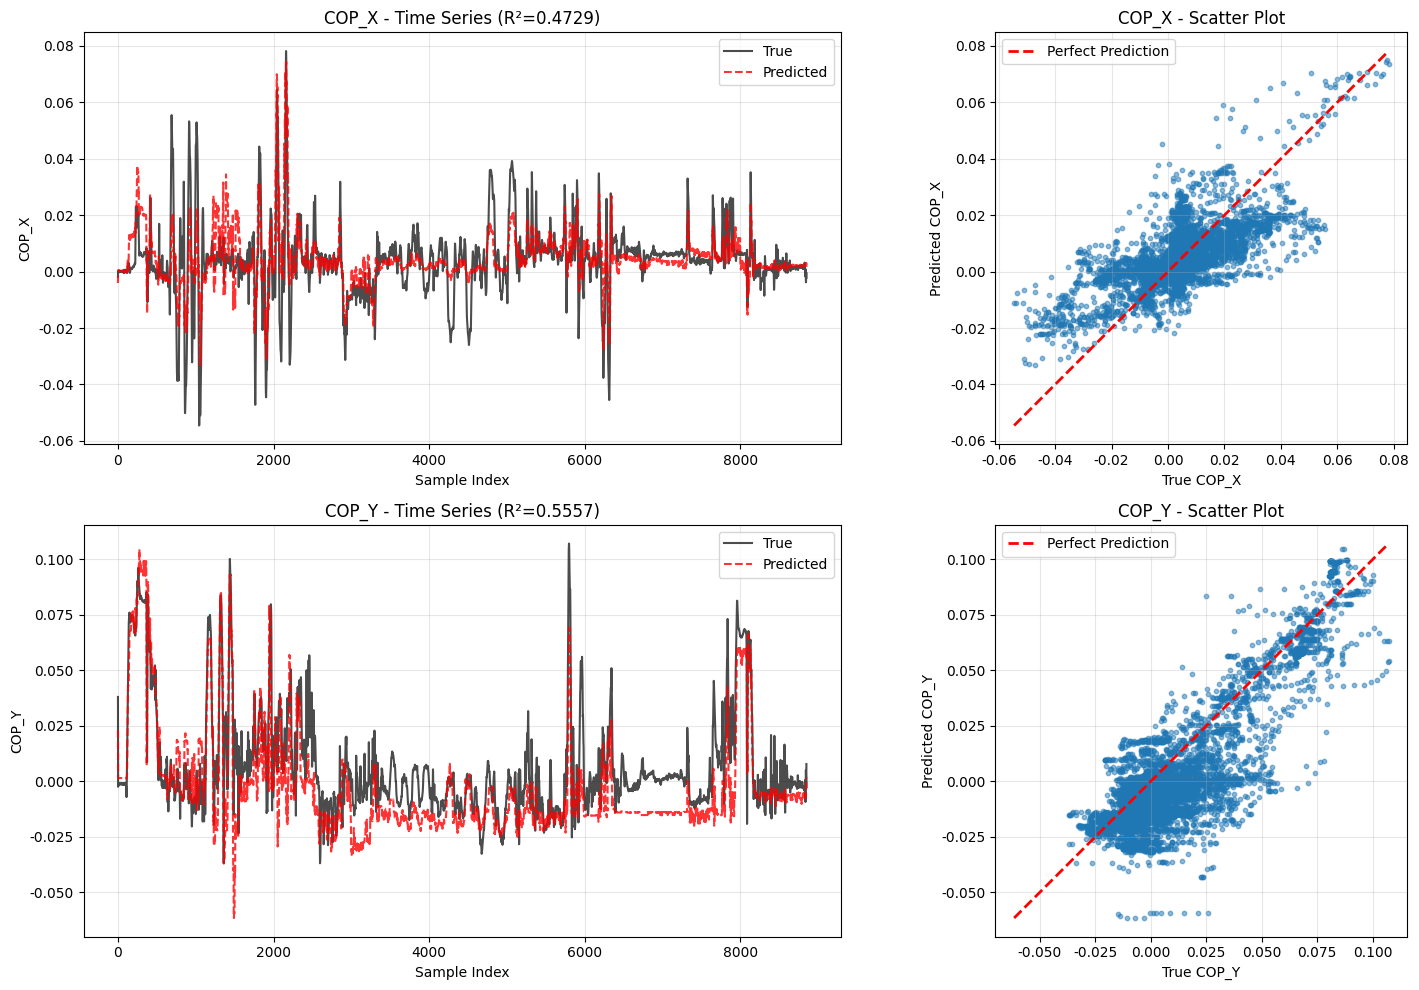

In [7]:

if __name__ == "__main__":
    # df_allが存在する場合のみ実行
    if 'df_all' in globals() or 'df_all' in locals():
        artifacts, results = main(df_all)
        plt.show()
    else:
        print("Error: df_all not found.")
        print("Please load your data first and define df_all DataFrame.")